# PROJECT OUTLINE
This Notebook covers phases as a multipurpose project for an Ecommerce Retail Franchise based in Nairobi, Kenya. The Stakeholders at the Franchise would would like to understand three important business metrics:
1. Customer churn rate for their business and what is the actual customer retention rate?
2. Fraud detection rate  in respect to financial transcations made at various retail mall outlets distributed across the country.

## PROJECT BREAKDOWN
- This project is broken down into various distinct phases that are well outlined and documented 

### PART A: SETTING UP THE ENVIRONMENT
This phase involved setting up our JupyterNotebook environment by installing necessary library packages and loading the necessary data to be analyzed.

In [1]:
#Installing the necessary library packages
!pip install numpy
!pip install pandas
!pip install matplotlib
!pip install seaborn
!pip install statsmodels
!pip install scipy
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [1]:
## Importing the Libraries into our jupyternotebook Environment
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy
import sklearn

## Data Investigation
Data Investigation, is a very integral part as it:
- Allows us to understand te structure of the data into further details.
- Allows cleaning of data into a more consistent format.
- Understand further patterns and distributions of the data.

In [2]:
## Load our data into data frame called (df)
pd.set_option('display.max_columns', None)   #This line of code ensures all columns in the data are dispalyed to the max.

In [3]:
df = pd.read_csv(r"C:\Users\Gifton\Videos\0.0002 DATA ANALYTICS\101_BINOMIAL_LOGISTIC\synthetic_ecommerce_order_risk_dataset.csv")
df.head(2)

,order_id,order_date,country,device_type,traffic_source,payment_method,product_category,customer_age_days,previous_orders,avg_order_value_eur,order_value_eur,quantity,discount_rate,shipping_distance_km,delivery_days_estimated,late_delivery_risk,address_mismatch,high_risk_ip,customer_support_contacts,review_score,is_returned,is_fraud,risk_label
0,ORD-2024-001936,1/3/2024,Belgium,Mobile,Paid Ads,Credit Card,Sports,381,3,28.66,33.71,2,0.12,105.7,5,0,0,0,0,4.4,0,0,Normal
1,ORD-2025-006495,11/26/2025,Netherlands,Desktop,Email,Debit Card,Garden,561,6,41.93,73.29,3,0.03,528.2,4,0,0,0,0,4.8,0,0,Normal


In [4]:
## Create a copy of the data to allow future Cleaning and Exploratory Analysis.
df_1 = df.copy()
df_1.head(2)

,order_id,order_date,country,device_type,traffic_source,payment_method,product_category,customer_age_days,previous_orders,avg_order_value_eur,order_value_eur,quantity,discount_rate,shipping_distance_km,delivery_days_estimated,late_delivery_risk,address_mismatch,high_risk_ip,customer_support_contacts,review_score,is_returned,is_fraud,risk_label
0,ORD-2024-001936,1/3/2024,Belgium,Mobile,Paid Ads,Credit Card,Sports,381,3,28.66,33.71,2,0.12,105.7,5,0,0,0,0,4.4,0,0,Normal
1,ORD-2025-006495,11/26/2025,Netherlands,Desktop,Email,Debit Card,Garden,561,6,41.93,73.29,3,0.03,528.2,4,0,0,0,0,4.8,0,0,Normal


In [5]:
df_1.columns

Index(['order_id', 'order_date', 'country', 'device_type', 'traffic_source',
       'payment_method', 'product_category', 'customer_age_days',
       'previous_orders', 'avg_order_value_eur', 'order_value_eur', 'quantity',
       'discount_rate', 'shipping_distance_km', 'delivery_days_estimated',
       'late_delivery_risk', 'address_mismatch', 'high_risk_ip',
       'customer_support_contacts', 'review_score', 'is_returned', 'is_fraud',
       'risk_label'],
      dtype='object')

In [6]:
## Obtain a Quality Information Report for our data
def data_quality_check(df_1):
    info_report = { 'shape':df_1.shape,
                    'total_records':len(df_1),
                    'missing_records': df_1.isnull().sum(),
                    'duplicate_rows':df_1.duplicated().sum()
                  }
    return info_report
info_report = data_quality_check(df_1)
print(info_report)

{'shape': (12000, 23), 'total_records': 12000, 'missing_records': order_id                     0
order_date                   0
country                      0
device_type                  0
traffic_source               0
payment_method               0
product_category             0
customer_age_days            0
previous_orders              0
avg_order_value_eur          0
order_value_eur              0
quantity                     0
discount_rate                0
shipping_distance_km         0
delivery_days_estimated      0
late_delivery_risk           0
address_mismatch             0
high_risk_ip                 0
customer_support_contacts    0
review_score                 0
is_returned                  0
is_fraud                     0
risk_label                   0
dtype: int64, 'duplicate_rows': np.int64(0)}


### Data Quality  Check Interpretation
- There are a total of 12000 records.
- There are 12000 Rows and 23 Columns within the dataset.
- There are no missing records
- There are no duplicate records found.

## Exploratory Data Analysis
We would like to understand the various data types within the dataset and if each of column values are respresented according to the data type.

In [7]:
## Obtain the Data types in our data
df_1.dtypes

order_id                      object
order_date                    object
country                       object
device_type                   object
traffic_source                object
payment_method                object
product_category              object
customer_age_days              int64
previous_orders                int64
avg_order_value_eur          float64
order_value_eur              float64
quantity                       int64
discount_rate                float64
shipping_distance_km         float64
delivery_days_estimated        int64
late_delivery_risk             int64
address_mismatch               int64
high_risk_ip                   int64
customer_support_contacts      int64
review_score                 float64
is_returned                    int64
is_fraud                       int64
risk_label                    object
dtype: object

### Data Type formatting.
The Order Date Column was an Object, Now adjusted to Datetime to truly reflect its actual data type.

In [8]:
## Adjust the Date type of Order_Date to a DATE TYPE
df_1['order_date'] = pd.to_datetime(df_1['order_date'])
df_1.head(1)

,order_id,order_date,country,device_type,traffic_source,payment_method,product_category,customer_age_days,previous_orders,avg_order_value_eur,order_value_eur,quantity,discount_rate,shipping_distance_km,delivery_days_estimated,late_delivery_risk,address_mismatch,high_risk_ip,customer_support_contacts,review_score,is_returned,is_fraud,risk_label
0,ORD-2024-001936,2024-01-03,Belgium,Mobile,Paid Ads,Credit Card,Sports,381,3,28.66,33.71,2,0.12,105.7,5,0,0,0,0,4.4,0,0,Normal


In [9]:
df_1.dtypes

order_id                             object
order_date                   datetime64[ns]
country                              object
device_type                          object
traffic_source                       object
payment_method                       object
product_category                     object
customer_age_days                     int64
previous_orders                       int64
avg_order_value_eur                 float64
order_value_eur                     float64
quantity                              int64
discount_rate                       float64
shipping_distance_km                float64
delivery_days_estimated               int64
late_delivery_risk                    int64
address_mismatch                      int64
high_risk_ip                          int64
customer_support_contacts             int64
review_score                        float64
is_returned                           int64
is_fraud                              int64
risk_label                      

### Breakdown Analysis and Structuring of the Columns and Obtain a brie Statistical Description of what they represent.
- According to the data types obtained as above, the Columns can either be Numerical or Categorical

In [10]:
## For NUMERICAL COLUMNS vs CATEGORICAL COLUMNS
numerical_cols =  df_1.select_dtypes(include =['float64','datetime64','int64'])
categorical_cols = df_1.select_dtypes(include=['object'])

In [11]:
## Obtain the Statistical Breakdown for each COLUMN Category
numerical_stats = numerical_cols.describe()
numerical_stats

,order_date,customer_age_days,previous_orders,avg_order_value_eur,order_value_eur,quantity,discount_rate,shipping_distance_km,delivery_days_estimated,late_delivery_risk,address_mismatch,high_risk_ip,customer_support_contacts,review_score,is_returned,is_fraud
count,12000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000
mean,2024-07-09 12:16:19.199999744,352.789083,1.943417,48.940278,61.053339,2.171833,0.146857,479.196567,4.058917,0.060000,0.048583,0.044167,0.200667,4.412433,0.092667,0.037250
min,2023-01-01 00:00:00,5.000000,0.000000,8.000000,5.000000,1.000000,0.000000,5.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.300000,0.000000,0.000000
25%,2023-10-10 00:00:00,177.000000,1.000000,29.070000,26.617500,1.000000,0.060000,236.100000,3.000000,0.000000,0.000000,0.000000,0.000000,4.100000,0.000000,0.000000
50%,2024-07-13 00:00:00,299.000000,1.000000,42.100000,45.335000,2.000000,0.120000,404.450000,4.000000,0.000000,0.000000,0.000000,0.000000,4.500000,0.000000,0.000000
75%,2025-04-12 00:00:00,475.000000,3.000000,61.010000,75.952500,3.000000,0.210000,645.225000,5.000000,0.000000,0.000000,0.000000,0.000000,4.900000,0.000000,0.000000
max,2025-12-31 00:00:00,1832.000000,13.000000,350.450000,810.750000,8.000000,0.750000,2589.700000,9.000000,1.000000,1.000000,1.000000,5.000000,5.000000,1.000000,1.000000
std,NaN,237.556088,1.902590,28.716864,55.540429,1.625534,0.113934,330.305205,1.105312,0.237497,0.215004,0.205474,0.478803,0.545286,0.289977,0.189382


In [12]:
categorical_stats = categorical_cols.describe()
categorical_stats

,order_id,country,device_type,traffic_source,payment_method,product_category,risk_label
count,12000,12000,12000,12000,12000,12000,12000
unique,12000,8,3,6,6,8,3
top,ORD-2024-001936,Netherlands,Mobile,Organic Search,Credit Card,Home & Kitchen,Normal
freq,1,3388,7354,2950,3984,2468,10482


### Distributions and Patterns
- This enables one to visualize how each of the Column is Distributed,  allowing spotting of trends and patterns, Check for presence of outliers and then Make Necessary Changes before further analysis is done.

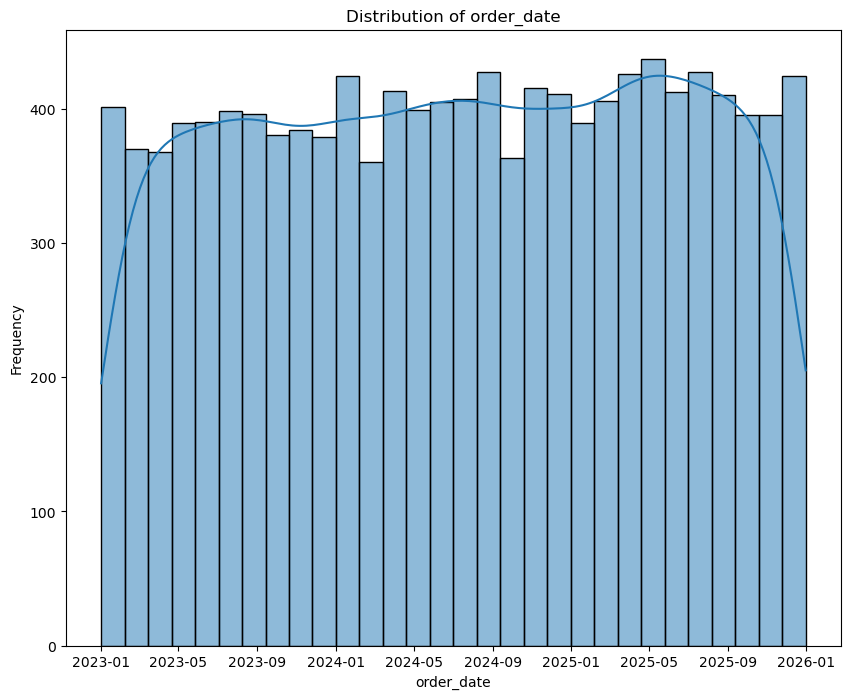

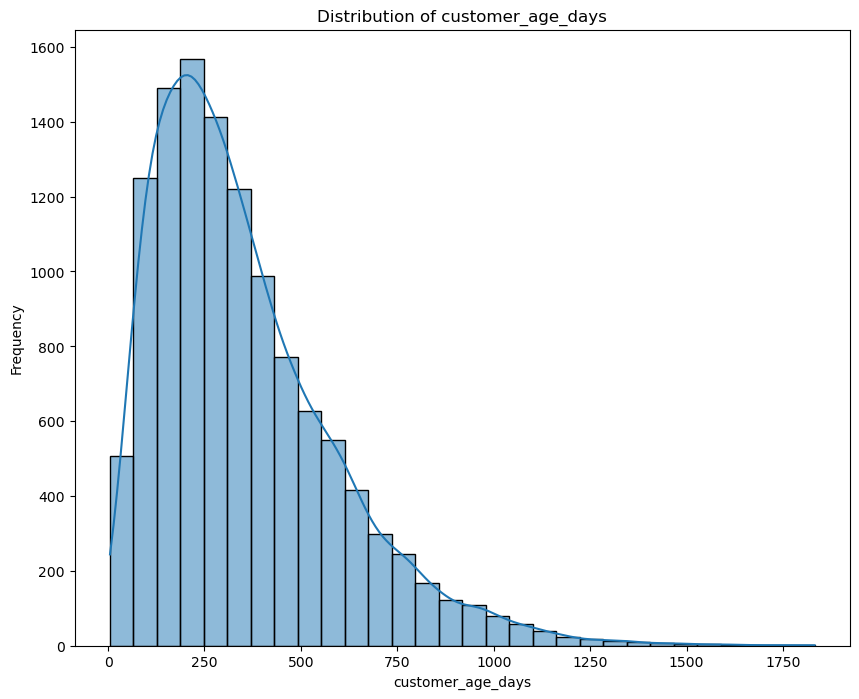

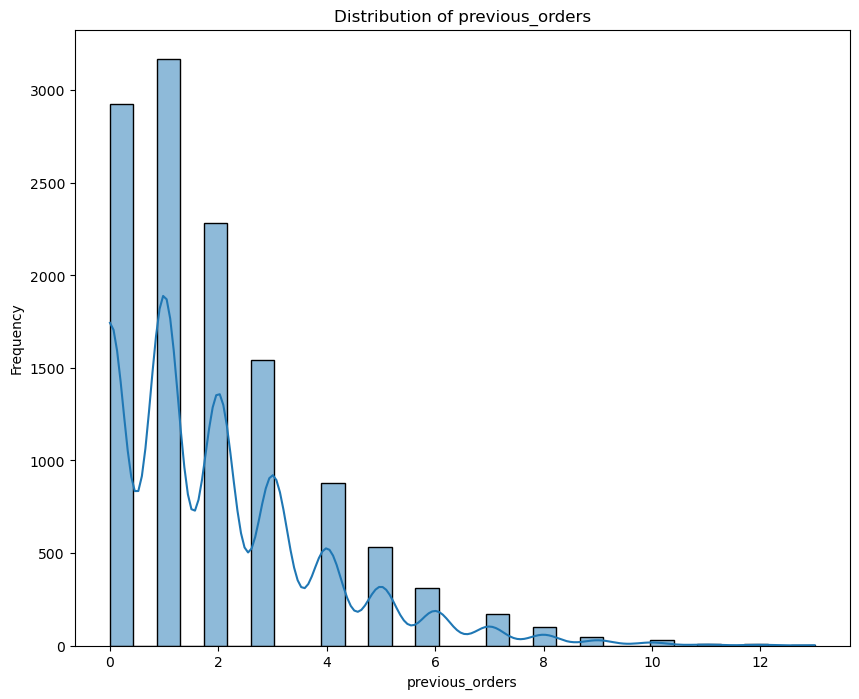

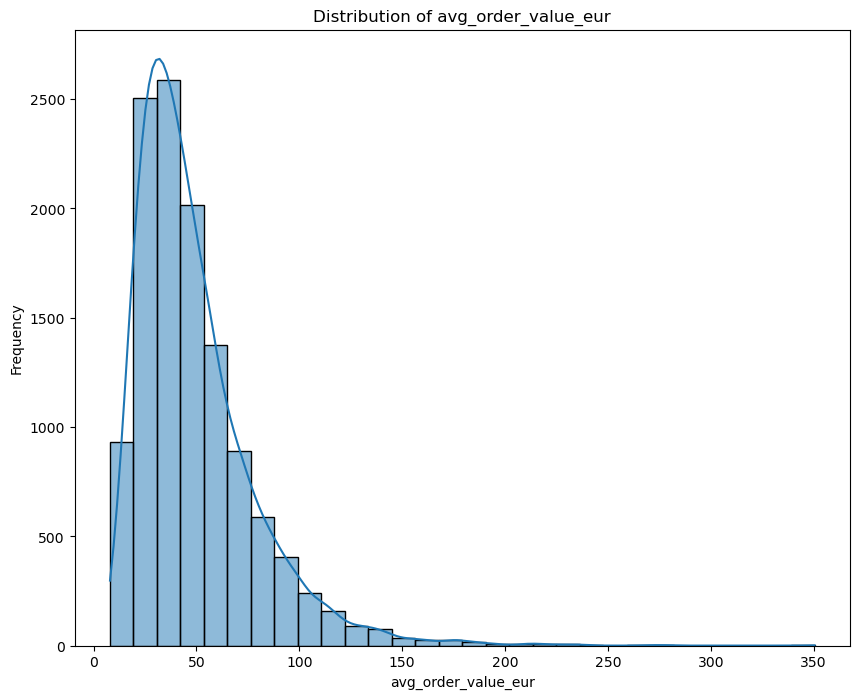

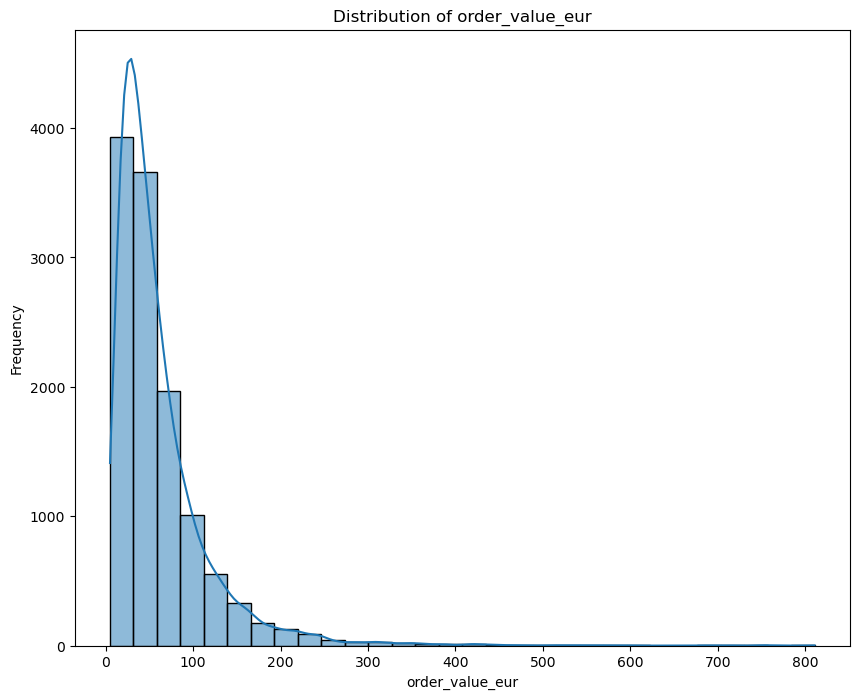

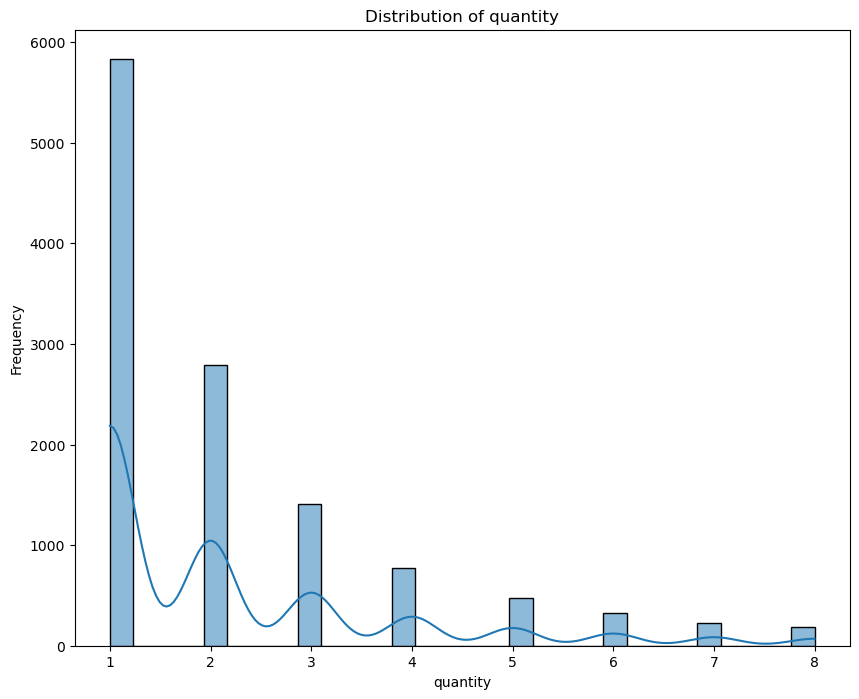

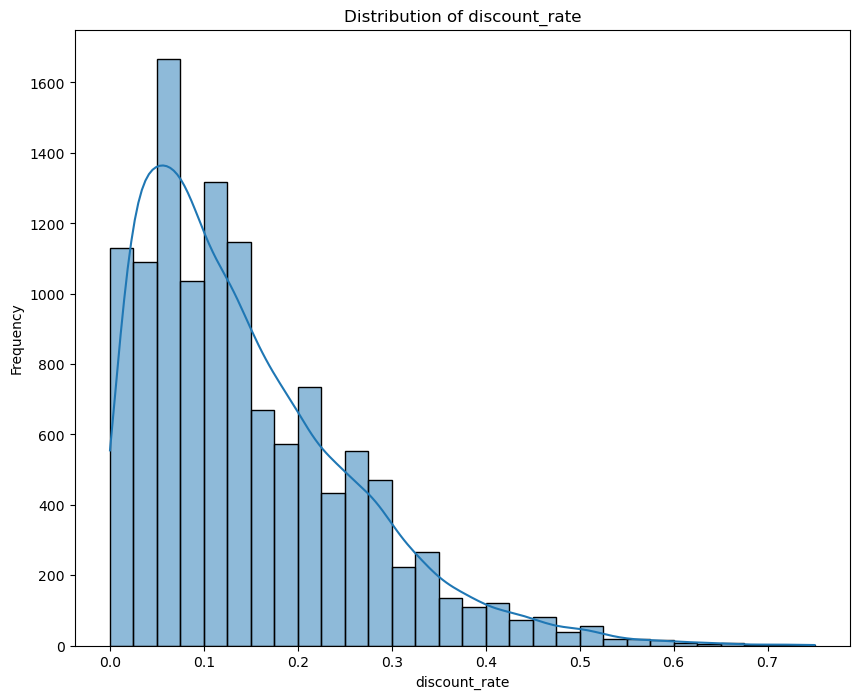

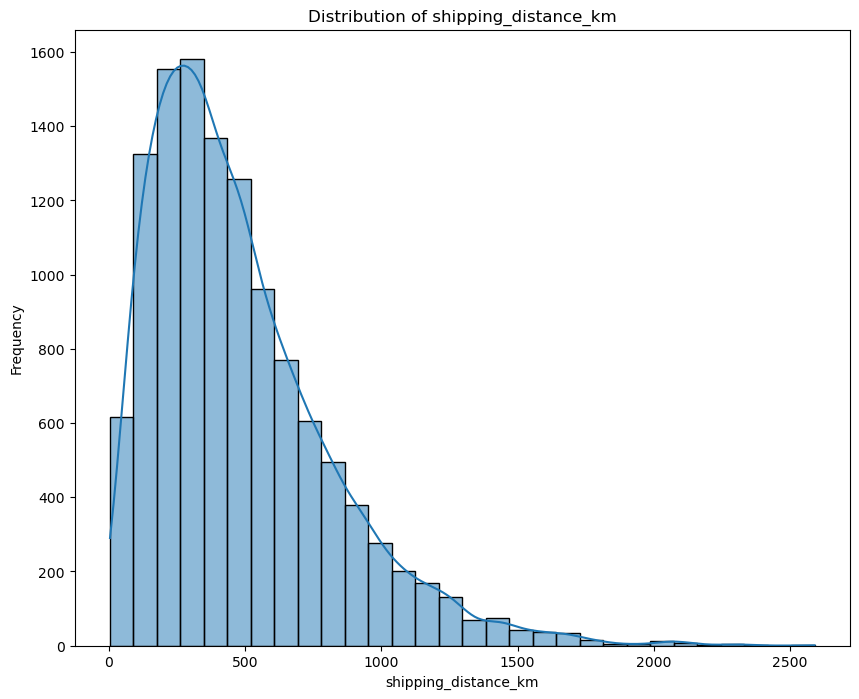

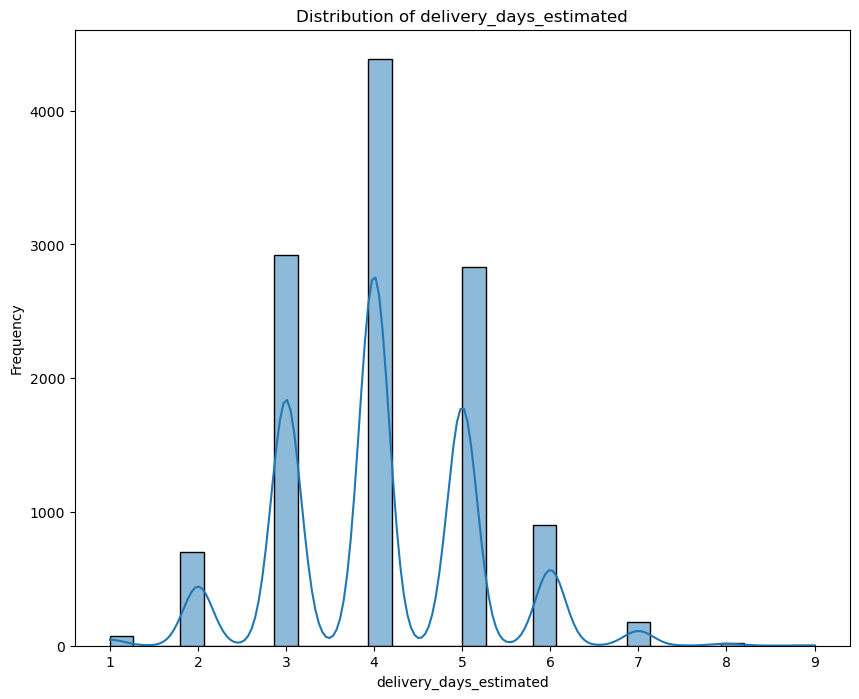

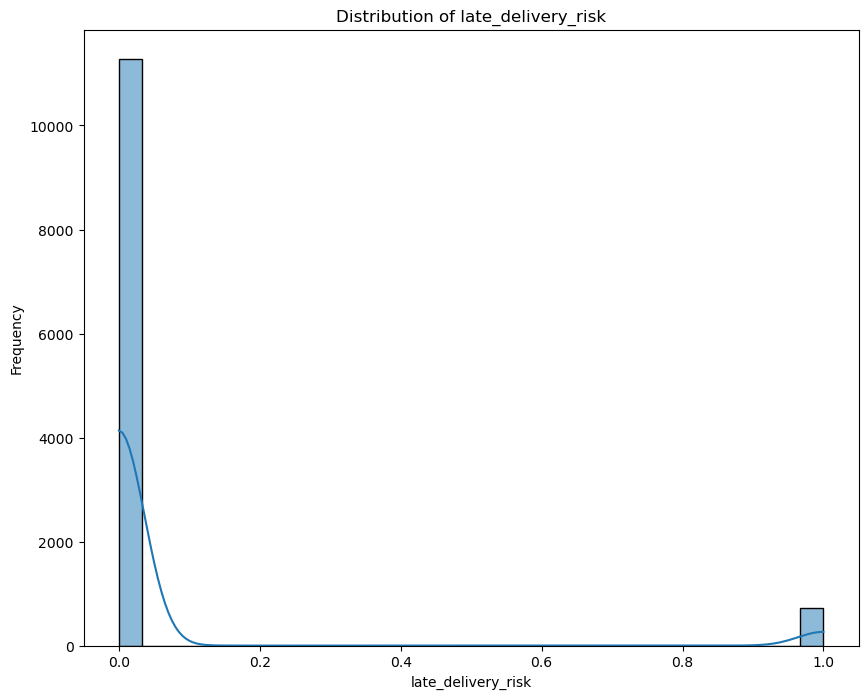

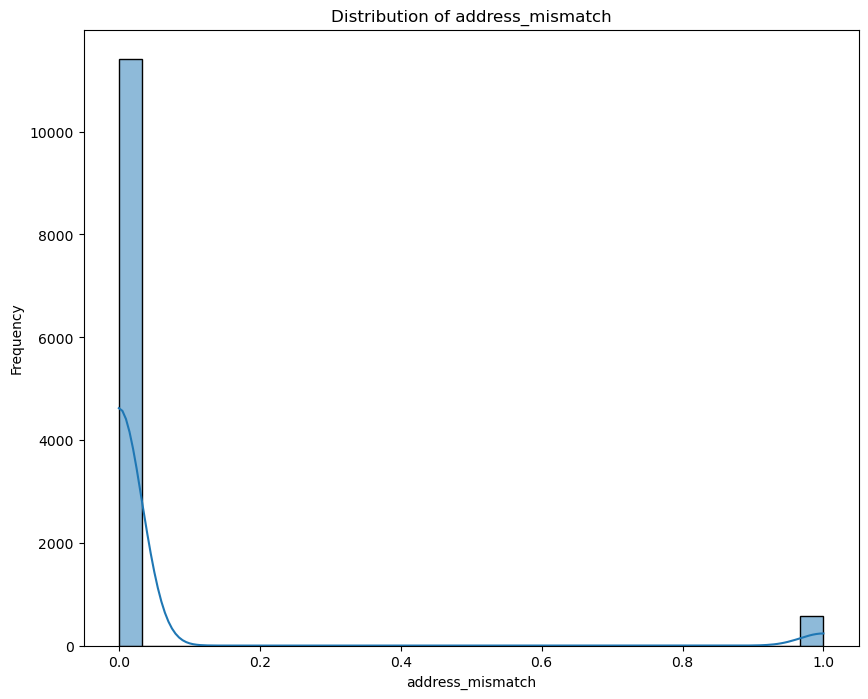

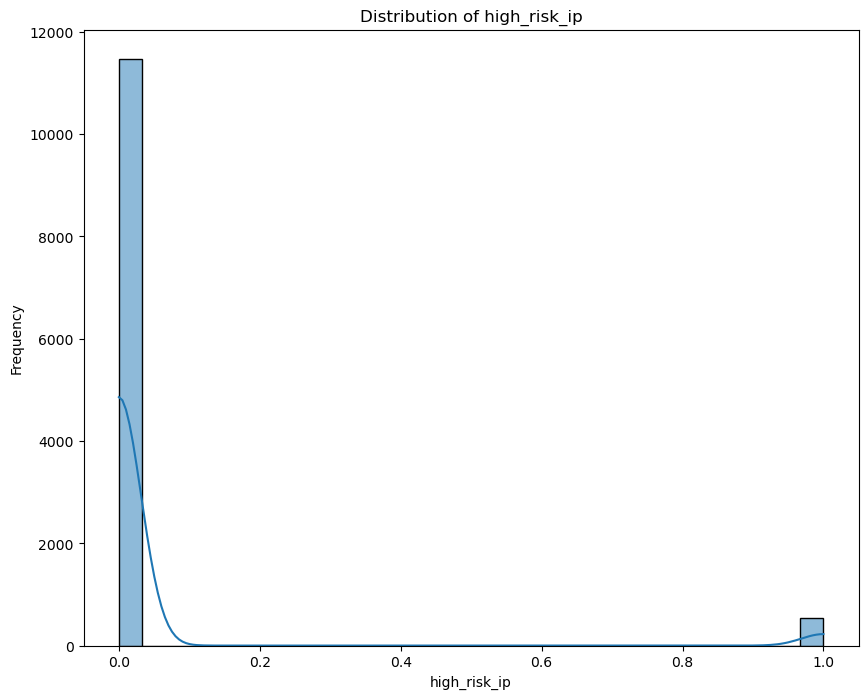

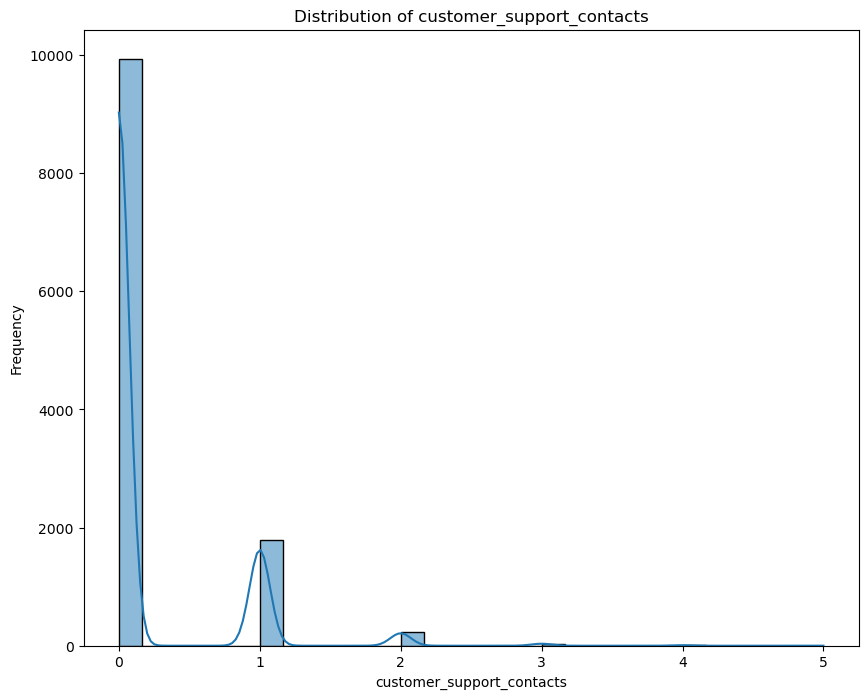

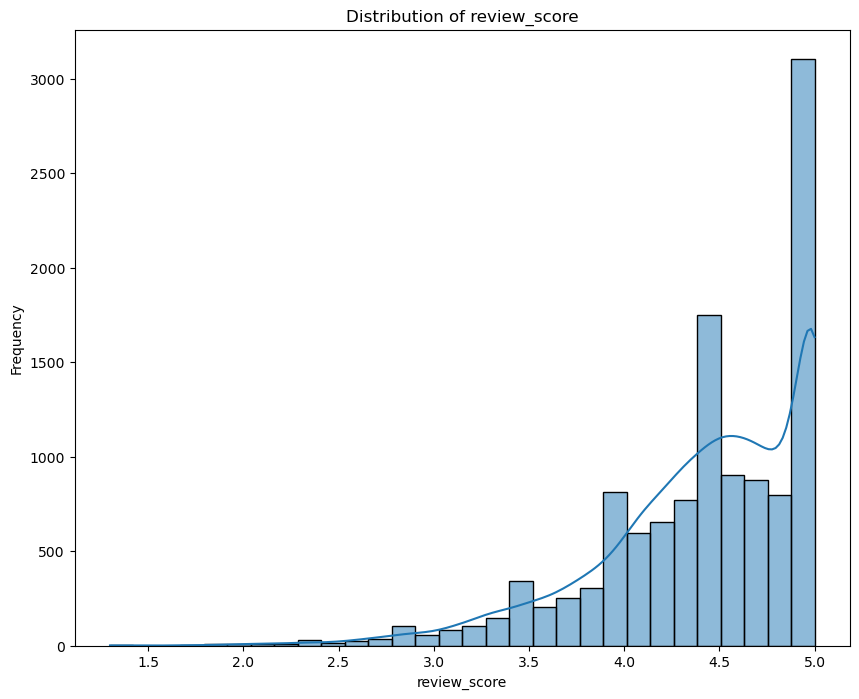

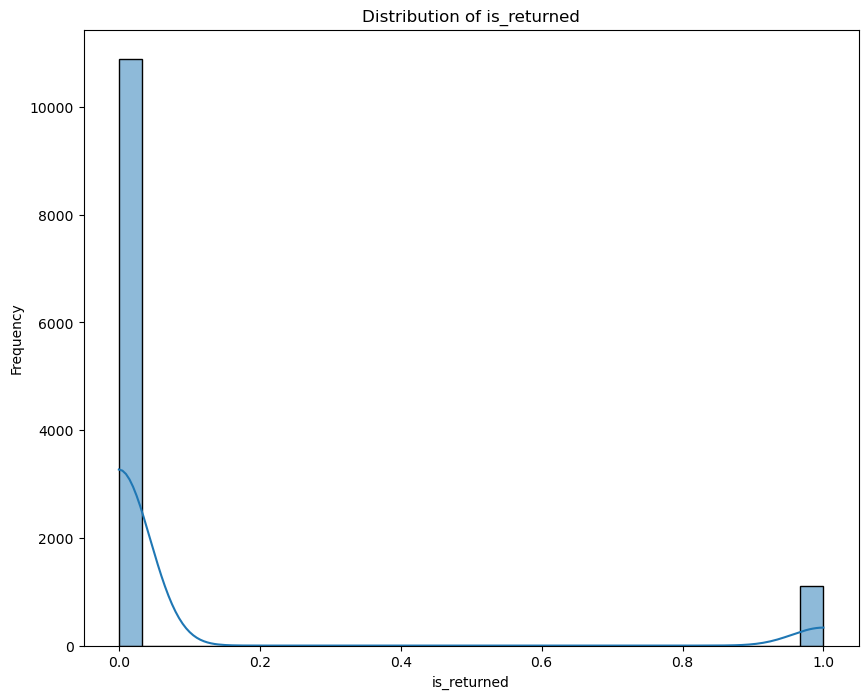

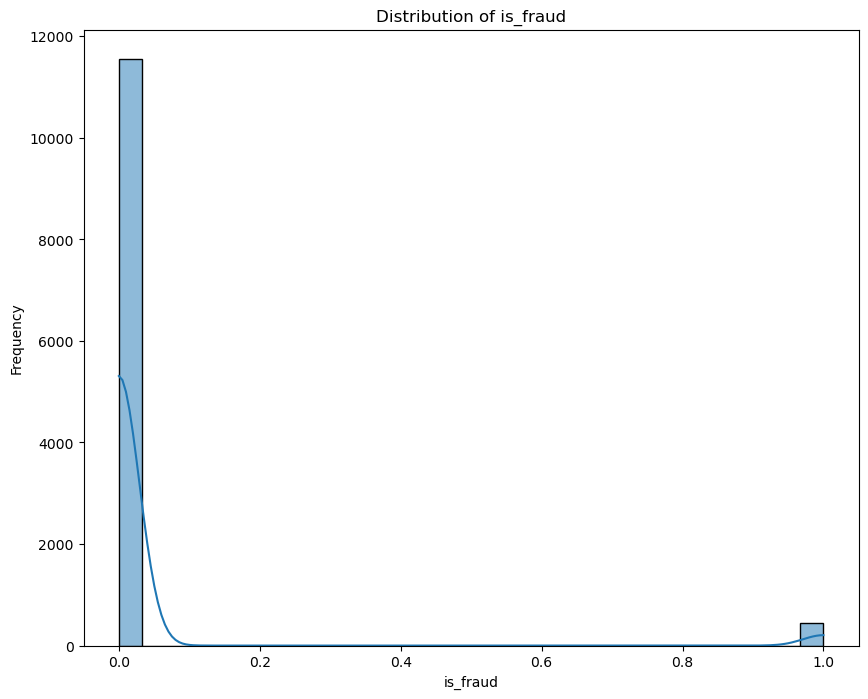

In [13]:
## Obtain distribution for Columns Types
## For Numerical cols:
for col in numerical_cols:
    plt.figure(figsize=(10,8))
    sns.histplot(df_1[col], kde=True, bins=30)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

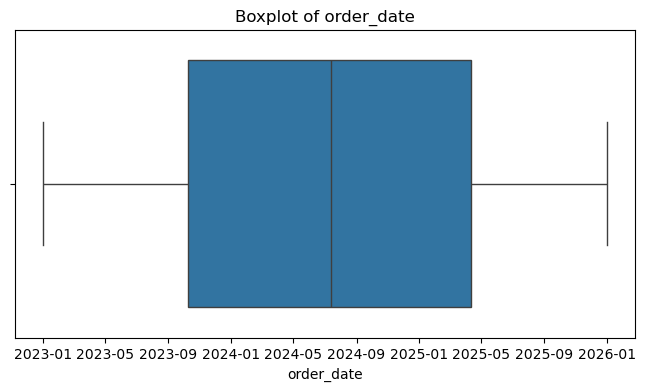

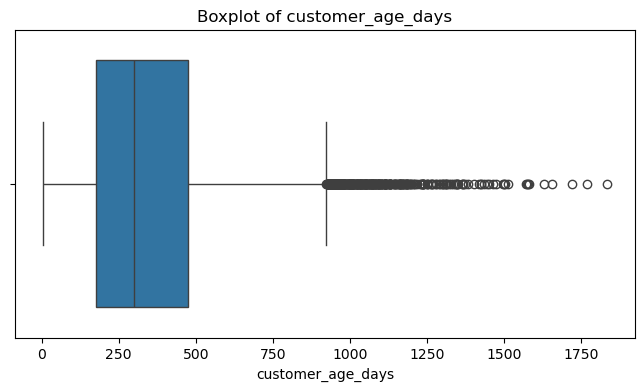

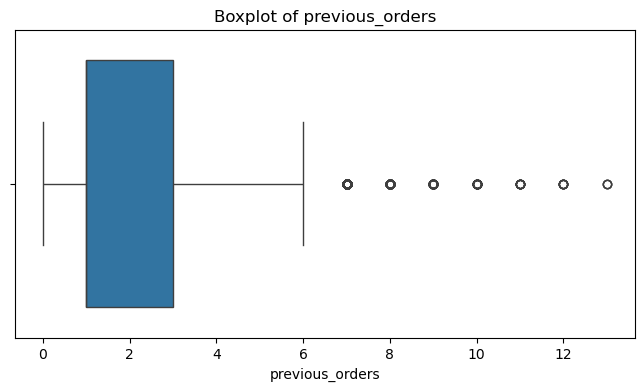

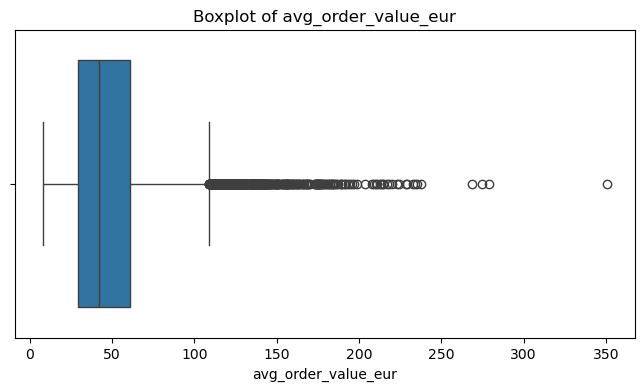

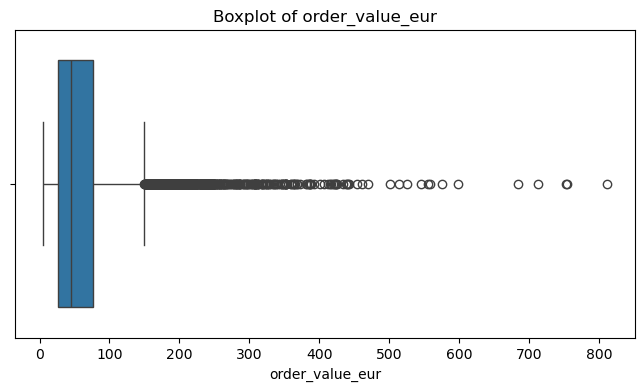

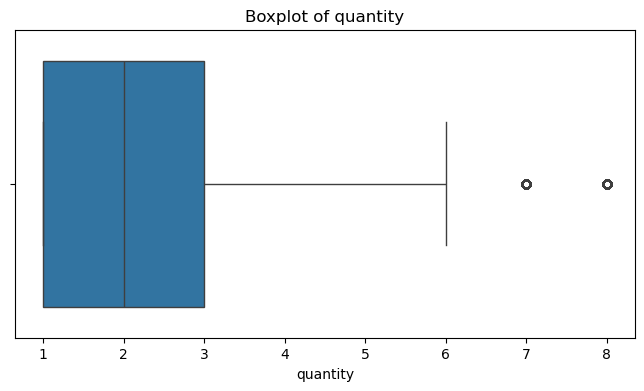

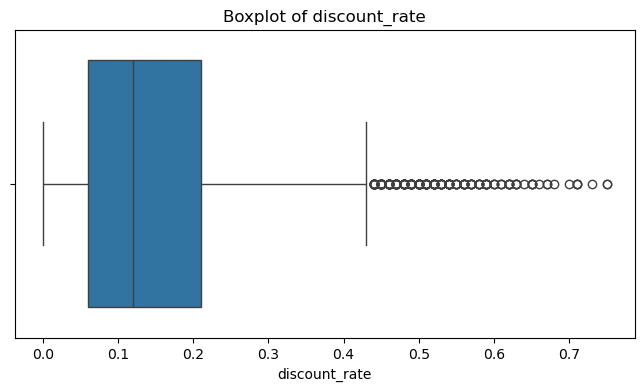

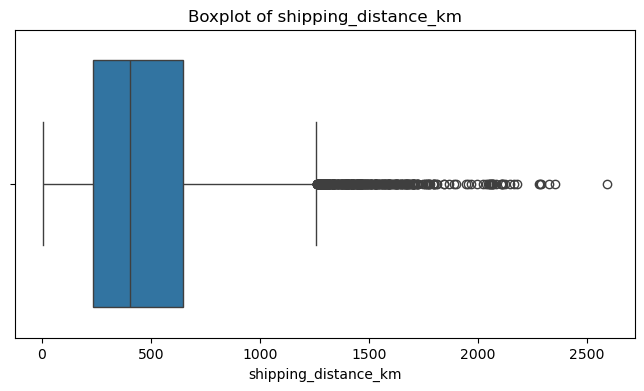

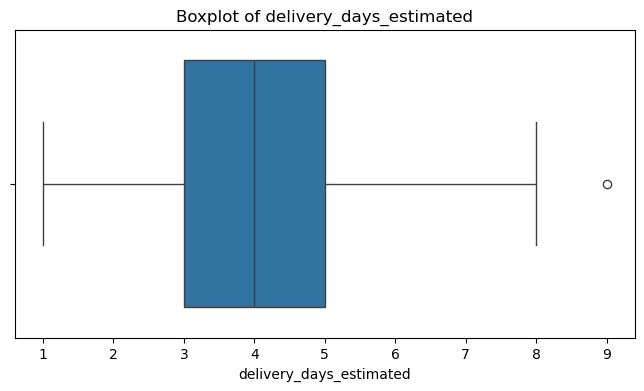

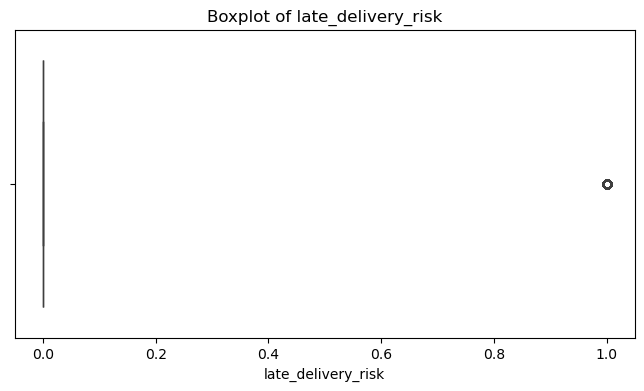

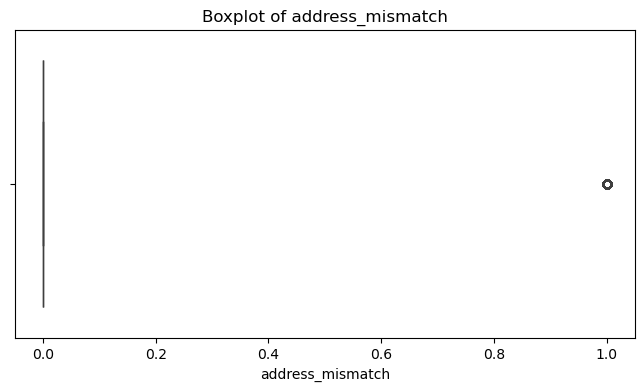

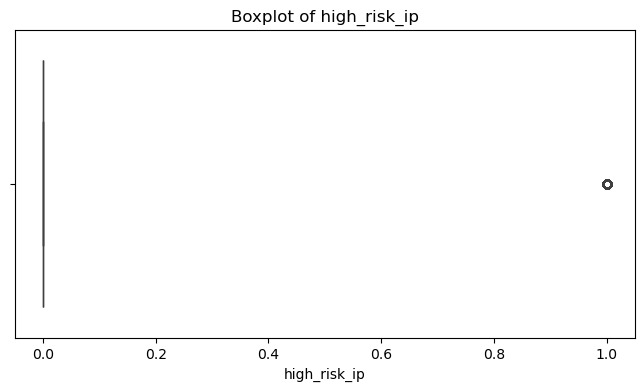

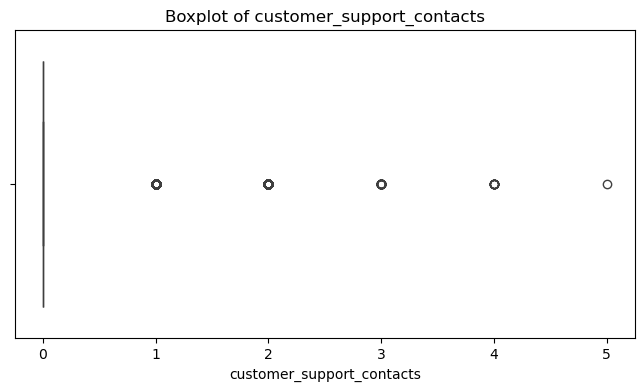

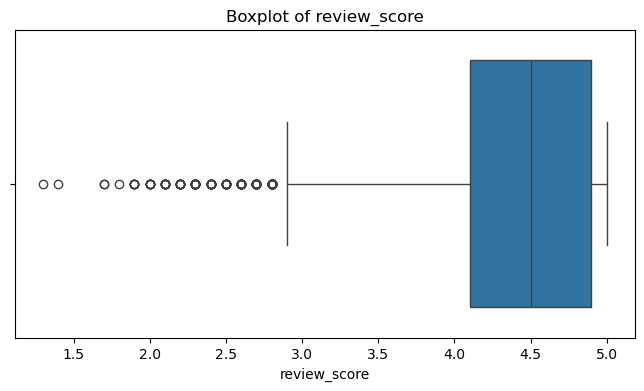

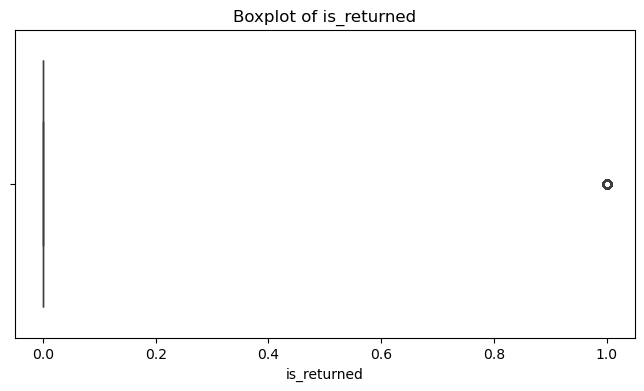

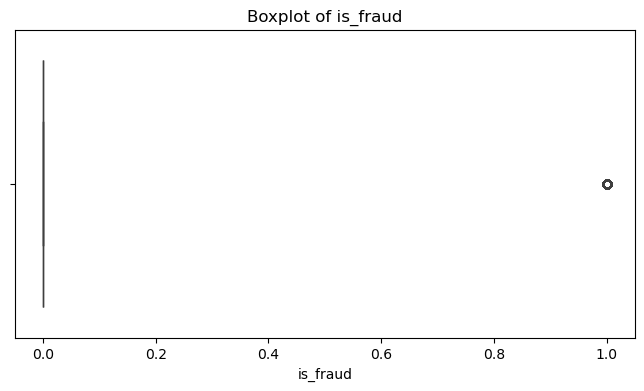

In [14]:
## Checking for Any Outliers in Numerical Columns
for col in numerical_cols:
    plt.figure(figsize=(8,4))
    sns.boxplot(x=df_1[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

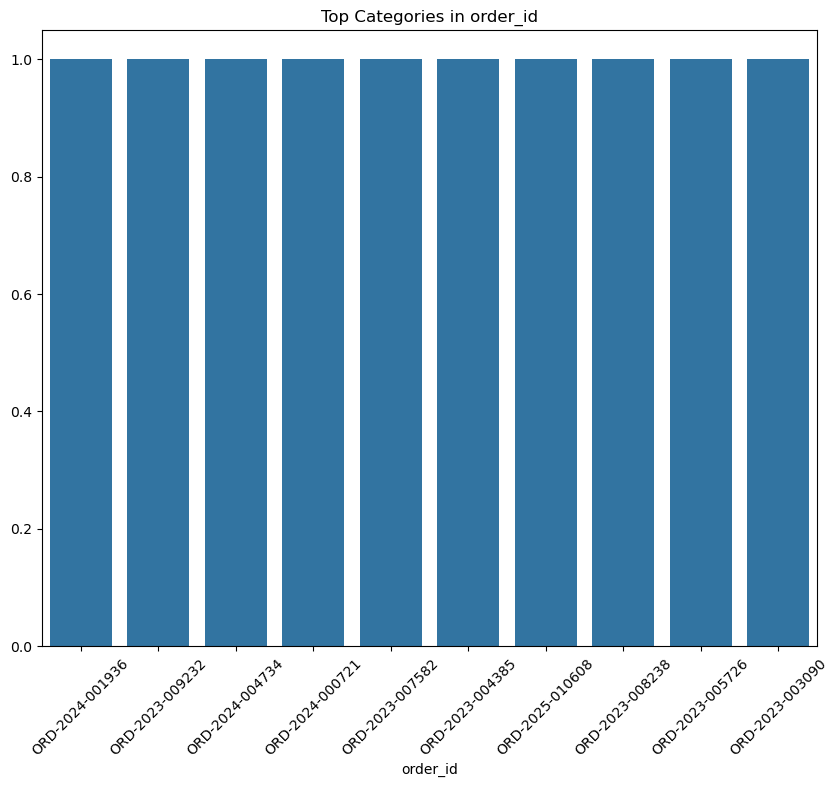

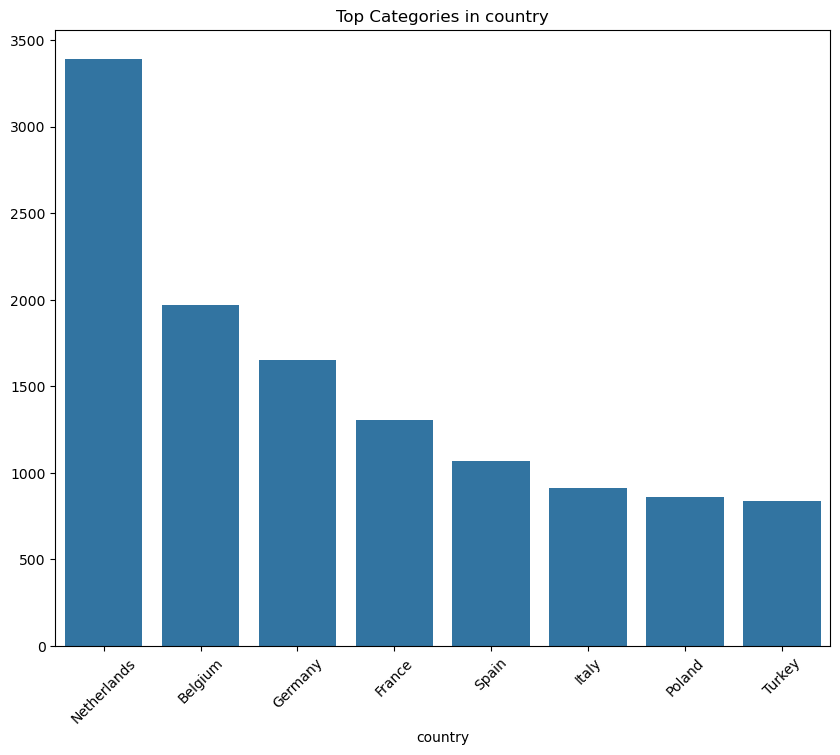

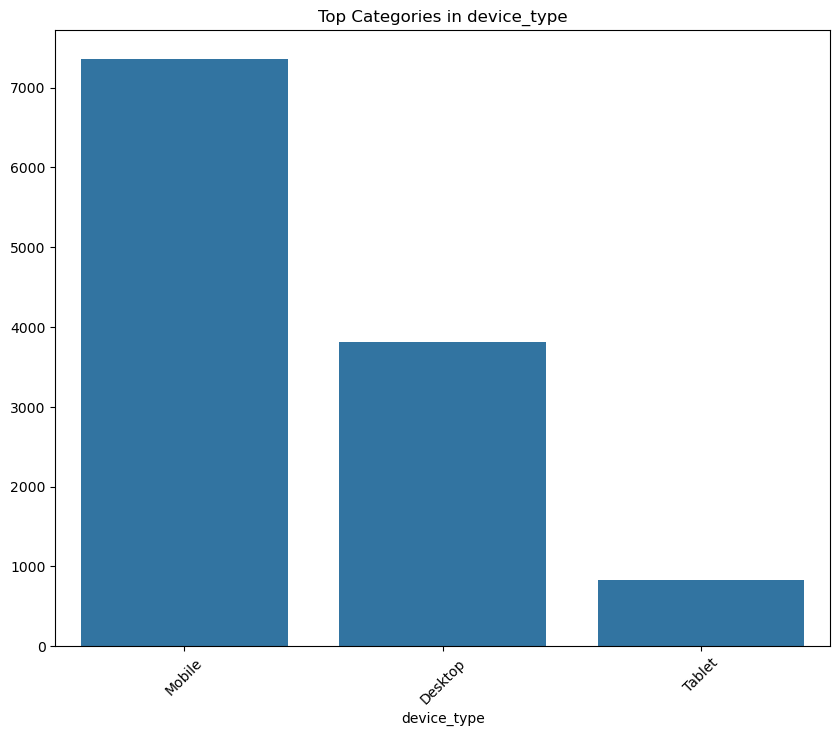

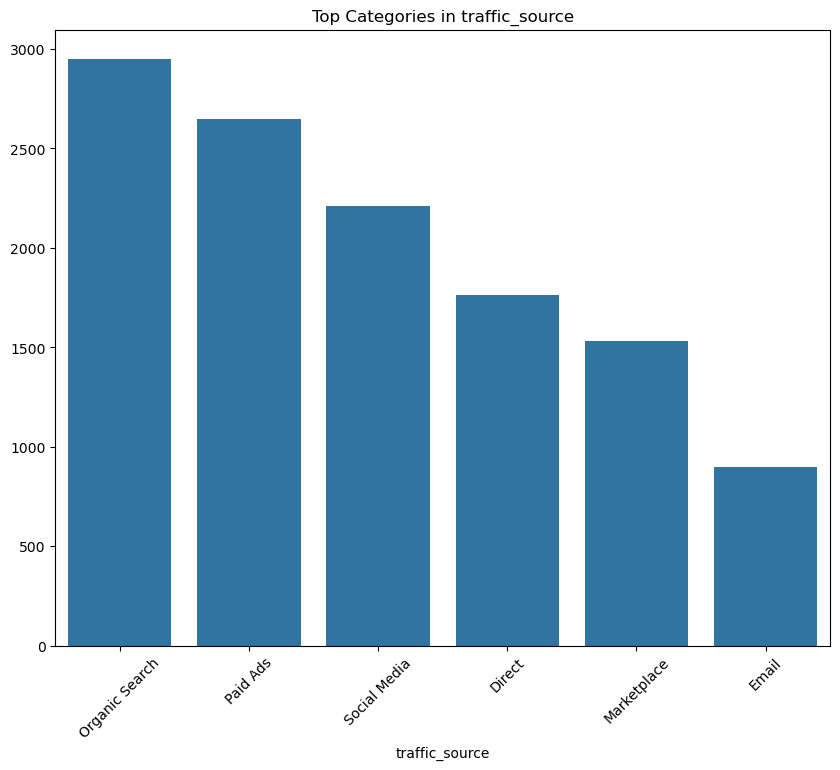

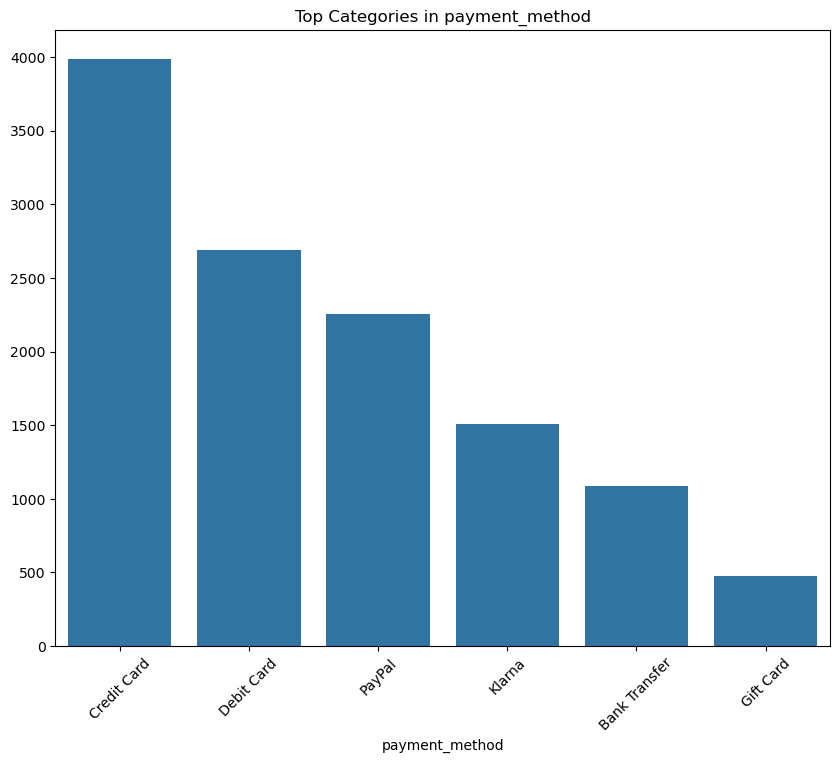

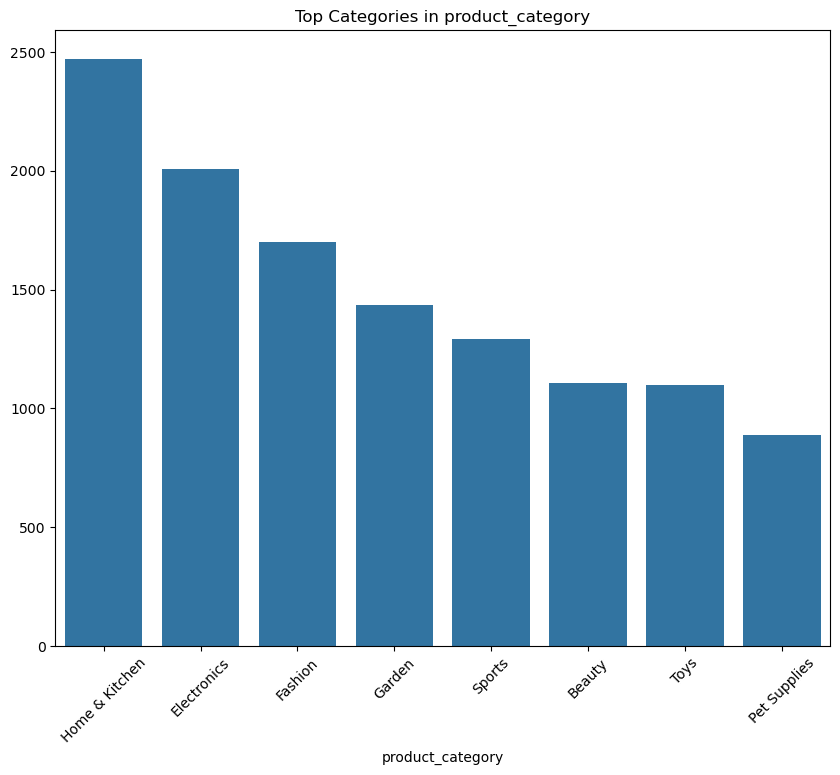

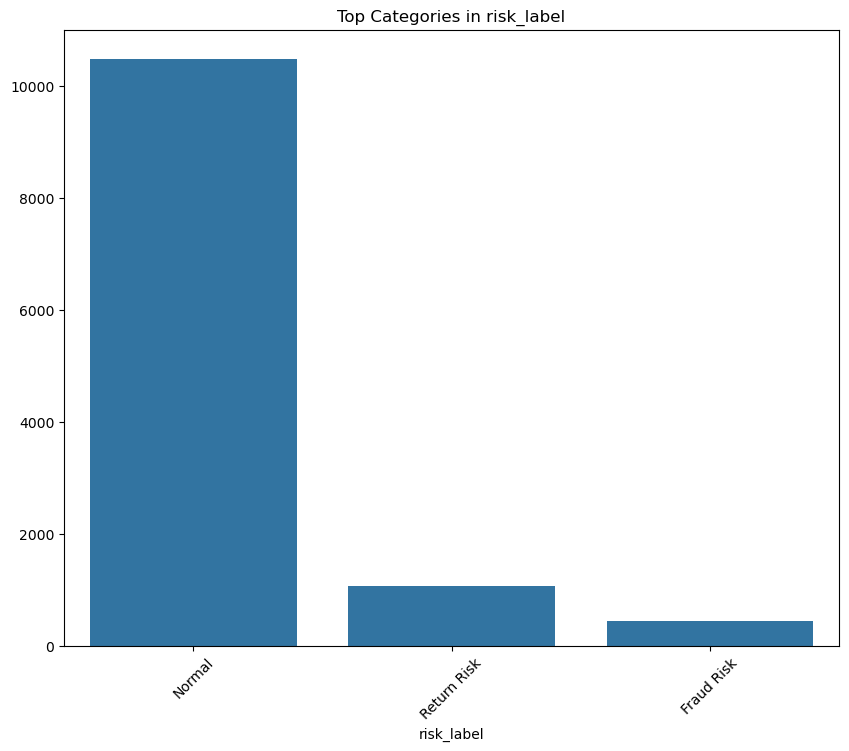

In [15]:
## Distributions in Categorical Columns
for col in categorical_cols:
    top_n=df_1[col].value_counts().nlargest(10)
    plt.figure(figsize=(10,8))
    sns.barplot(x=top_n.index, y=top_n.values)
    plt.title(f"Top Categories in {col}")
    plt.xticks(rotation=45)
    plt.show()
                                            

### How imbalanced are the target variables?
Our project Target variables are:
- Is Returned?
- Is Fraud?
- The Risk Label.

Best use case is balancing extreme outliers.


In [16]:
df.columns

Index(['order_id', 'order_date', 'country', 'device_type', 'traffic_source',
       'payment_method', 'product_category', 'customer_age_days',
       'previous_orders', 'avg_order_value_eur', 'order_value_eur', 'quantity',
       'discount_rate', 'shipping_distance_km', 'delivery_days_estimated',
       'late_delivery_risk', 'address_mismatch', 'high_risk_ip',
       'customer_support_contacts', 'review_score', 'is_returned', 'is_fraud',
       'risk_label'],
      dtype='object')

In [17]:
print(df_1['is_returned'].value_counts(normalize = True)) 
print(df_1['is_fraud'].value_counts(normalize = True))
print(df_1['risk_label'].value_counts(normalize = True))

is_returned
0    0.907333
1    0.092667
Name: proportion, dtype: float64
is_fraud
0    0.96275
1    0.03725
Name: proportion, dtype: float64
risk_label
Normal         0.87350
Return Risk    0.08925
Fraud Risk     0.03725
Name: proportion, dtype: float64


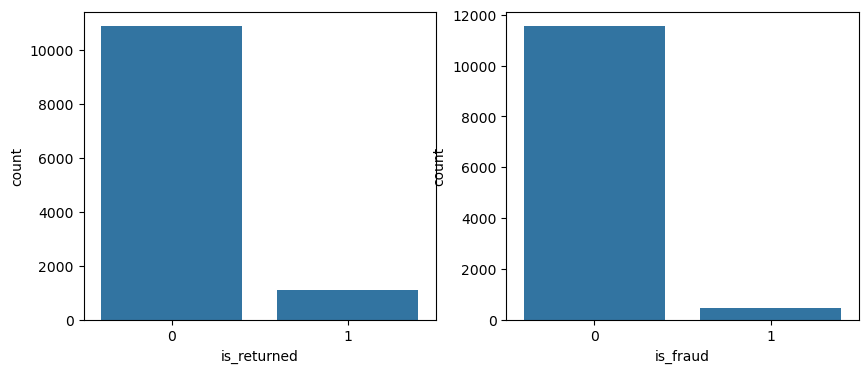

In [18]:
## Lets Visualize the plots
fig, axes = plt.subplots(1,2,figsize=(10,4))
sns.countplot(x='is_returned', data=df_1, ax=axes[0])
sns.countplot(x='is_fraud', data=df_1, ax=axes[1])
plt.show()

### Are the Numeric Features Multicollinear (Highly correlated with each other?)

In [19]:
df_1.columns

Index(['order_id', 'order_date', 'country', 'device_type', 'traffic_source',
       'payment_method', 'product_category', 'customer_age_days',
       'previous_orders', 'avg_order_value_eur', 'order_value_eur', 'quantity',
       'discount_rate', 'shipping_distance_km', 'delivery_days_estimated',
       'late_delivery_risk', 'address_mismatch', 'high_risk_ip',
       'customer_support_contacts', 'review_score', 'is_returned', 'is_fraud',
       'risk_label'],
      dtype='object')

In [20]:
df_1.head(1)

,order_id,order_date,country,device_type,traffic_source,payment_method,product_category,customer_age_days,previous_orders,avg_order_value_eur,order_value_eur,quantity,discount_rate,shipping_distance_km,delivery_days_estimated,late_delivery_risk,address_mismatch,high_risk_ip,customer_support_contacts,review_score,is_returned,is_fraud,risk_label
0,ORD-2024-001936,2024-01-03,Belgium,Mobile,Paid Ads,Credit Card,Sports,381,3,28.66,33.71,2,0.12,105.7,5,0,0,0,0,4.4,0,0,Normal


In [21]:
numerical_cols =df_1[['customer_age_days','previous_orders','avg_order_value_eur','order_value_eur','quantity','discount_rate','shipping_distance_km','delivery_days_estimated','late_delivery_risk','address_mismatch','high_risk_ip','customer_support_contacts','review_score','is_returned','is_fraud']]
numerical_cols

,customer_age_days,previous_orders,avg_order_value_eur,order_value_eur,quantity,discount_rate,shipping_distance_km,delivery_days_estimated,late_delivery_risk,address_mismatch,high_risk_ip,customer_support_contacts,review_score,is_returned,is_fraud
0,381,3,28.66,33.71,2,0.12,105.7,5,0,0,0,0,4.4,0,0
1,561,6,41.93,73.29,3,0.03,528.2,4,0,0,0,0,4.8,0,0
2,324,2,102.67,55.49,1,0.05,175.1,5,0,0,0,0,3.3,0,0
3,378,3,72.71,112.54,5,0.22,271.4,3,0,0,0,0,4.2,1,0
4,447,5,52.26,55.32,8,0.25,285.3,3,0,1,0,0,5.0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11995,742,3,25.75,25.75,1,0.31,121.4,3,0,0,0,1,4.5,0,0
11996,152,1,96.29,118.35,2,0.09,225.5,4,0,0,0,0,5.0,0,0
11997,130,0,114.14,114.13,1,0.08,669.6,5,0,0,0,0,4.5,0,0
11998,203,1,21.60,25.58,1,0.23,229.4,5,0,0,0,0,4.4,0,0


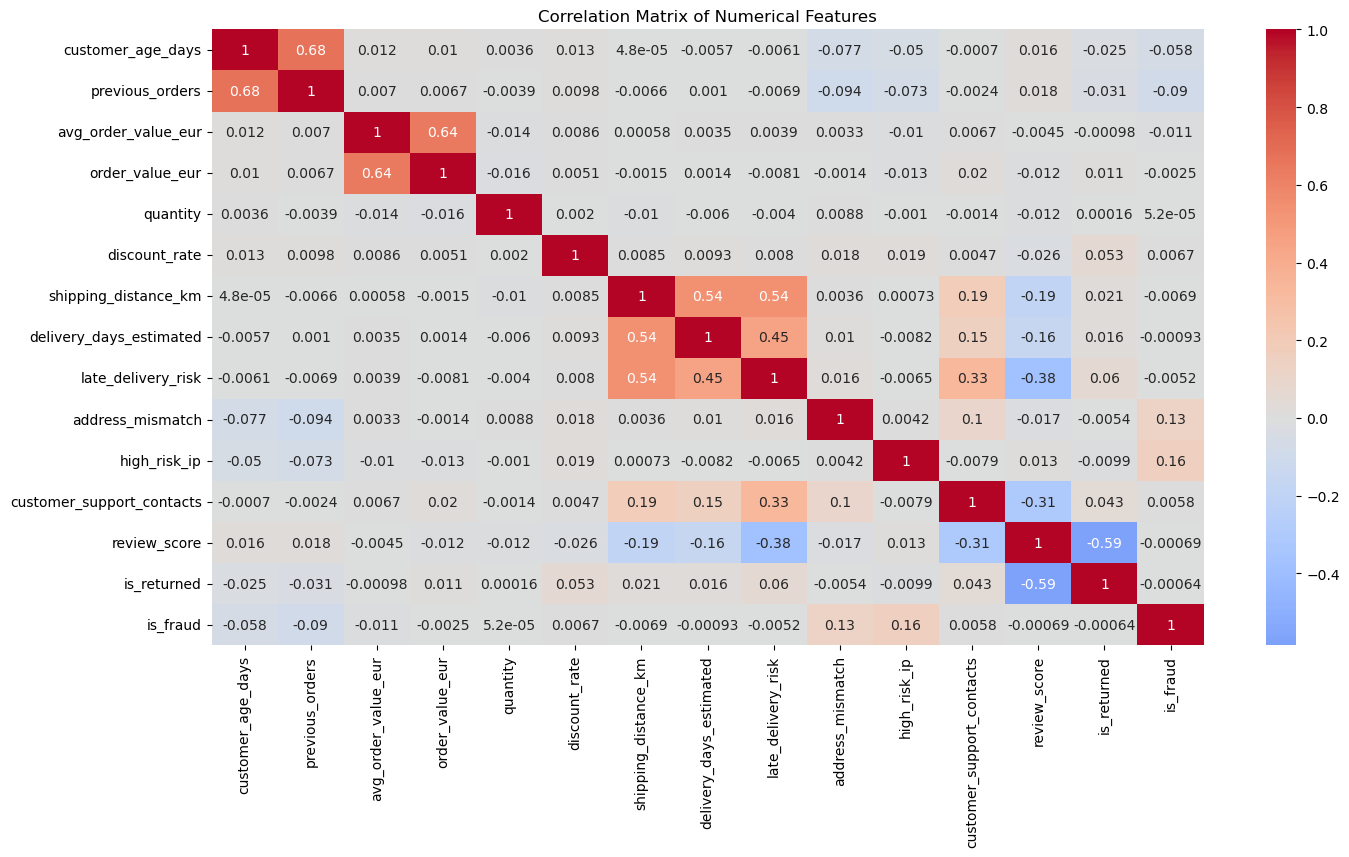

In [22]:
plt.figure(figsize=(16,8))
corr_matrix = numerical_cols.corr()
sns.heatmap(corr_matrix, annot =True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix of Numerical Features')
plt.show()

## A.MODEL BUILDING (RETURN  RATE PREDICTION)
This section involves model building (A Binomial Logistic Regression to Model (RETURN PREDICTION)
- RETURN PREDICTION: The Goal is to determine or rather predict if yes or not that a customer will return the product back to the Retail store.

In [23]:
!pip install scikit-learn

In this case we shall be using Two Functions from the Scikit Learn Module.
- Scikit Learn Module is a powerful library used for Data Science and Advanced Machine Learning.
- The Train_Test_Split() will be used for Training and Testing our data Model
- The Logistic Regression will be used to fit a Logistic Regression Model.  

In [24]:
from sklearn.model_selection import train_test_split

In [25]:
from sklearn.linear_model import LogisticRegression

- During this Phase we shall be Building a Logistic Regression Model to Model the relationship if a Product is returned. (If "Returned = Yes"). The Predictor variable of choice are: [Customer age days, Previous Orders and Quantity]

In [26]:
df_1.head(2)

,order_id,order_date,country,device_type,traffic_source,payment_method,product_category,customer_age_days,previous_orders,avg_order_value_eur,order_value_eur,quantity,discount_rate,shipping_distance_km,delivery_days_estimated,late_delivery_risk,address_mismatch,high_risk_ip,customer_support_contacts,review_score,is_returned,is_fraud,risk_label
0,ORD-2024-001936,2024-01-03,Belgium,Mobile,Paid Ads,Credit Card,Sports,381,3,28.66,33.71,2,0.12,105.7,5,0,0,0,0,4.4,0,0,Normal
1,ORD-2025-006495,2025-11-26,Netherlands,Desktop,Email,Debit Card,Garden,561,6,41.93,73.29,3,0.03,528.2,4,0,0,0,0,4.8,0,0,Normal


## PHASE 1 OF MODEL BUILDING: BIVARIATE MODELLING.
- In this Phase we shall be building a Binomial Logistic Regression to Model relationship between Customer age days and the Probability that a product is returned to the Retail Store[if "Returned = YES"]

In [27]:
## Subset the X and Y variables
X = df_1[['customer_age_days']]
y_returned = df_1[['is_returned']]

In [28]:
## Split data into training and hold out datasets
X_train,X_test,y_train,y_test = train_test_split(X, y_returned, test_size=0.3, random_state=42)

In [29]:
## Build a Classifier and then Fit The Model using the .fit() function
clf = LogisticRegression().fit(X_train, y_train)

C:\Users\Gifton\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [30]:
## Obtain the COEFFICIENTS AND INTERCEPTS
clf.coef_

array([[-0.00038293]])

In [31]:
clf.intercept_

array([-2.15458856])

<Axes: xlabel='customer_age_days', ylabel='is_returned'>

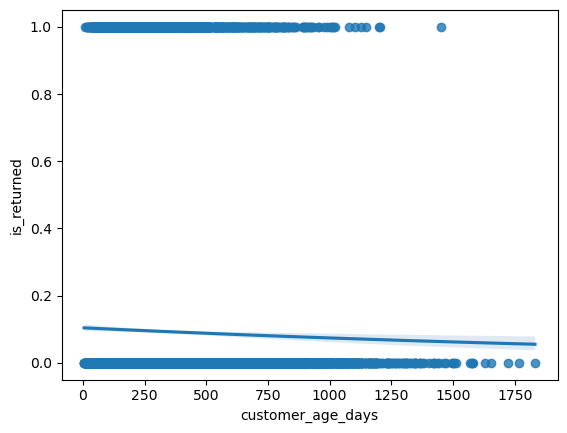

In [32]:
## Obtain the Visualizations
sns.regplot(x ='customer_age_days', y= 'is_returned', data=df_1, logistic=True)

### MODEL EVALUATION
How accurate was the Model at Predicting The Number of Products Returned. Case Example ('IS_RETURNED').
- In this part, we'll build a CONFUSION MATRIX, which is a graphical representation to evaluate how well the model performed at Classification.

In [33]:
## sTART by saving the PREDICTIONS AS:
y_pred = clf.predict(X_test)

In [34]:
## Print out the Predicted Labels
clf.predict(X_test)

array([0, 0, 0, ..., 0, 0, 0], shape=(3600,))

In [35]:
## Print out the probabilities
clf.predict_proba(X_test)[::-1]

array([[0.9076733 , 0.0923267 ],
       [0.90837687, 0.09162313],
       [0.90294721, 0.09705279],
       ...,
       [0.90451302, 0.09548698],
       [0.90050407, 0.09949593],
       [0.91922259, 0.08077741]], shape=(3600, 2))

In [36]:
# Import the metrics module from scikit-learn 
import sklearn.metrics as metrics


In [37]:
# Calculate the values for each quadrant in the confusion matrix
cm = metrics.confusion_matrix(y_test, y_pred, labels = clf.classes_)

In [38]:
# Create the confusion matrix as a visualization 
disp = metrics.ConfusionMatrixDisplay(confusion_matrix = cm,display_labels = clf.classes_) 

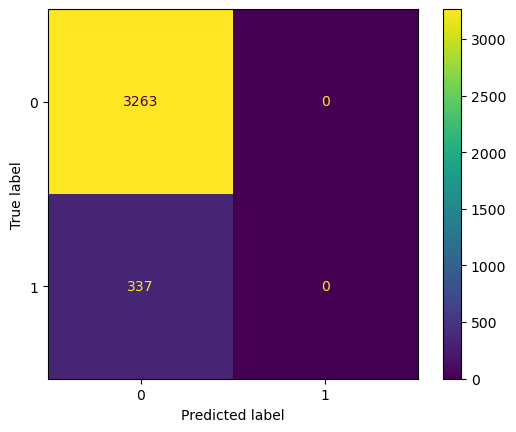

In [39]:
# Display the confusion matrix 
disp.plot()

### PHASE 2: MULTIVARIATE MODEL BUILDING. 
- In this phase we try building a Logistic Regression Model Based on More than one predictor Variable.
- On top of the Customer_age_days Variable, we shall be adding two MORE Variables (Previous_Orders and Quantity)

In [40]:
df_1.columns

Index(['order_id', 'order_date', 'country', 'device_type', 'traffic_source',
       'payment_method', 'product_category', 'customer_age_days',
       'previous_orders', 'avg_order_value_eur', 'order_value_eur', 'quantity',
       'discount_rate', 'shipping_distance_km', 'delivery_days_estimated',
       'late_delivery_risk', 'address_mismatch', 'high_risk_ip',
       'customer_support_contacts', 'review_score', 'is_returned', 'is_fraud',
       'risk_label'],
      dtype='object')

- Subsetting the X and Y variables from the data frame

In [41]:
## Defining the Predictor and  Y variables
X = df_1[['customer_age_days','previous_orders','quantity']]
y_returned = df_1[['is_returned']]

- Splitting the data into training and Hold outs
- We use test size as 0.3 so that the holdout dataset is only 30% of the total data.
- A random state of 42 ensures that the results are  easily reproducible.

In [42]:
## Split the data into TRAINING and HOLD OUT Datasets
X_train,X_test,y_train,y_test = train_test_split(X,y_returned, test_size=0.3, random_state=42)

- Building a CLASSIFIER: A Classifier allows for the Model to be fit.

In [43]:
clf = LogisticRegression().fit(X_train, y_train)

C:\Users\Gifton\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


## Obtaining the coefficients

In [44]:
clf.coef_

array([[-0.00014616, -0.04460081, -0.00643153]])

In [45]:
clf.intercept_

array([-2.13945912])

### Interpretations of the Model Coefficients and Intercepts
Log(odds) = B0 + B1X1 + B2X2 + B3X3:
- Where the B0 is the itercept, B1 is the coefficient for Customer_age_days, B2 is coefficient for Previous orders and B3 Is the coefficient for Quantity
Since each of the value of the coefficients is Negative, we can exponentiate each of the coefficient so as to obtain the ODDS RATIO.
- B1 = e^-0.000146 = 0.188
- B2 = e^-0.0446 = 0.9999
- B3 = e^-0,00643 = 0.9564

### EVALUATING THE MODEL

In [46]:
y_pred =clf.predict(X_test)

In [47]:
clf.predict_proba(X_test)[::,-1]

array([0.08575233, 0.10123279, 0.08984718, ..., 0.09359888, 0.09156069,
       0.08869454], shape=(3600,))

In [48]:
import sklearn.metrics as metrics

In [49]:
cm = metrics.confusion_matrix(y_test, y_pred, labels = clf.classes_)

In [50]:
disp = metrics.ConfusionMatrixDisplay(confusion_matrix = cm,display_labels = clf.classes_) 

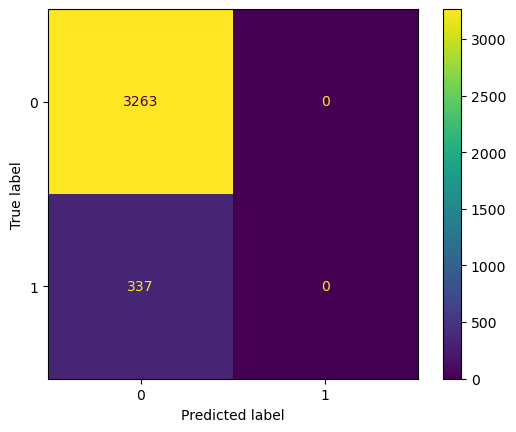

In [51]:
disp.plot()

### B. MODEL BULDING (FRAUD RATE DETECTION)

In [52]:
df_1.head(1)

,order_id,order_date,country,device_type,traffic_source,payment_method,product_category,customer_age_days,previous_orders,avg_order_value_eur,order_value_eur,quantity,discount_rate,shipping_distance_km,delivery_days_estimated,late_delivery_risk,address_mismatch,high_risk_ip,customer_support_contacts,review_score,is_returned,is_fraud,risk_label
0,ORD-2024-001936,2024-01-03,Belgium,Mobile,Paid Ads,Credit Card,Sports,381,3,28.66,33.71,2,0.12,105.7,5,0,0,0,0,4.4,0,0,Normal


In [53]:
df_1.columns

Index(['order_id', 'order_date', 'country', 'device_type', 'traffic_source',
       'payment_method', 'product_category', 'customer_age_days',
       'previous_orders', 'avg_order_value_eur', 'order_value_eur', 'quantity',
       'discount_rate', 'shipping_distance_km', 'delivery_days_estimated',
       'late_delivery_risk', 'address_mismatch', 'high_risk_ip',
       'customer_support_contacts', 'review_score', 'is_returned', 'is_fraud',
       'risk_label'],
      dtype='object')

In [54]:
X = df_1[['high_risk_ip']]
y_fraud =df_1[['is_fraud']]

In [55]:
X_train,X_test,y_train,y_test = train_test_split(X,y_fraud, test_size=0.3, random_state =42)

In [56]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

In [57]:
clf = LogisticRegression().fit(X_train, y_train)

C:\Users\Gifton\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [58]:
clf.coef_

array([[1.81073247]])

In [59]:
clf.intercept_

array([-3.40479302])

<Axes: xlabel='high_risk_ip', ylabel='is_fraud'>

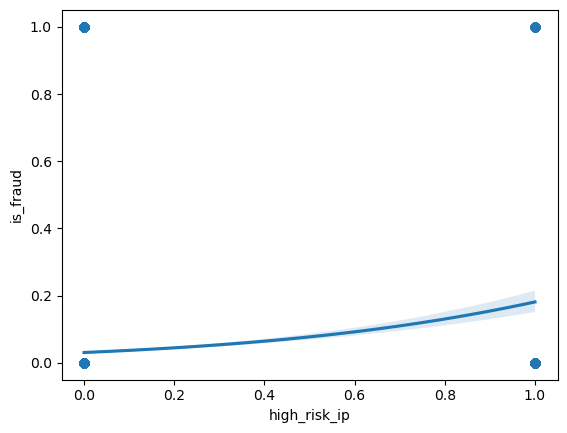

In [60]:
sns.regplot(x='high_risk_ip', y='is_fraud', data=df_1, logistic=True)

### MODEL EVALUATION

In [61]:
y_pred = clf.predict(X_test)

In [62]:
clf.predict(X_test)

array([0, 0, 0, ..., 0, 0, 0], shape=(3600,))

In [63]:
clf.predict_proba(X_test)[::,-1]


array([0.03214601, 0.03214601, 0.03214601, ..., 0.03214601, 0.03214601,
       0.03214601], shape=(3600,))

In [64]:
cm = metrics.confusion_matrix(y_test, y_pred, labels = clf.classes_)


In [65]:
disp = metrics.ConfusionMatrixDisplay(confusion_matrix = cm,display_labels = clf.classes_) 

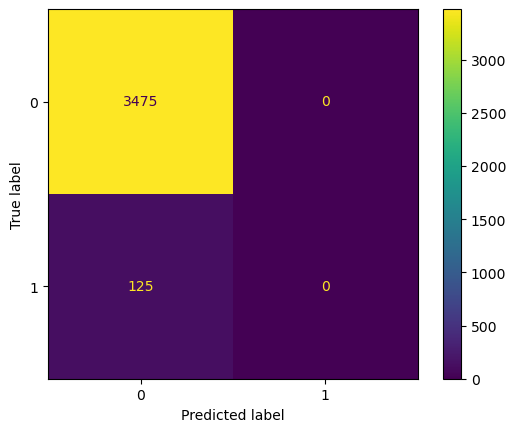

In [66]:
disp.plot()


# VISUALIZATIONS
We would like to visualize how the Logistic regression model is fit by the three predictor variables

In [67]:
df_1.columns

Index(['order_id', 'order_date', 'country', 'device_type', 'traffic_source',
       'payment_method', 'product_category', 'customer_age_days',
       'previous_orders', 'avg_order_value_eur', 'order_value_eur', 'quantity',
       'discount_rate', 'shipping_distance_km', 'delivery_days_estimated',
       'late_delivery_risk', 'address_mismatch', 'high_risk_ip',
       'customer_support_contacts', 'review_score', 'is_returned', 'is_fraud',
       'risk_label'],
      dtype='object')

C:\Users\Gifton\AppData\Local\Temp\ipykernel_3256\4028789822.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data = df_coefs, x = 'variable', y = 'coefficients', palette ='coolwarm')


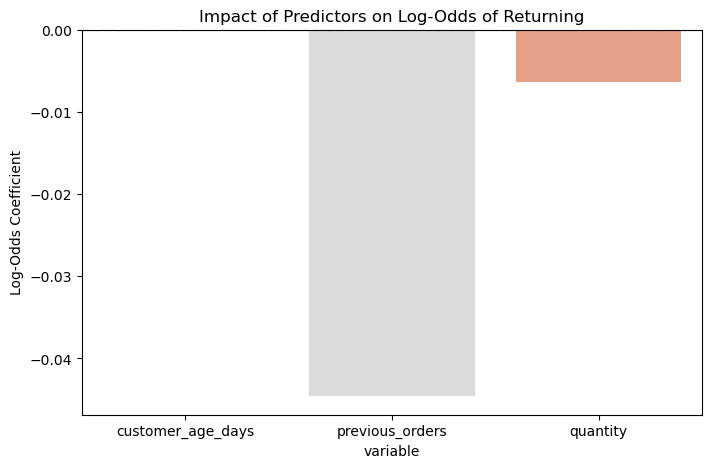

In [68]:
coefs = {'customer_age_days':-0.00014616, 
         'previous_orders':-0.04460081, 
         'quantity':-0.00643153}
intercept = -2.13945912

df_coefs = pd.DataFrame (
    list(coefs.items()),
    columns =['variable','coefficients']
)

plt.figure(figsize=(8,5))
sns.barplot(data = df_coefs, x = 'variable', y = 'coefficients', palette ='coolwarm')
plt.axhline(y=0, color='black', linestyle='--')
plt.title('Impact of Predictors on Log-Odds of Returning')
plt.ylabel('Log-Odds Coefficient')
plt.show()

In [31]:
df_coefs['odds_ratio'] = np.exp(df_coefs['coefficients'])
# Then plot 'odds_ratio' instead, and draw a horizontal line at y=1.

C:\Users\Gifton\AppData\Local\Temp\ipykernel_3256\379061019.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


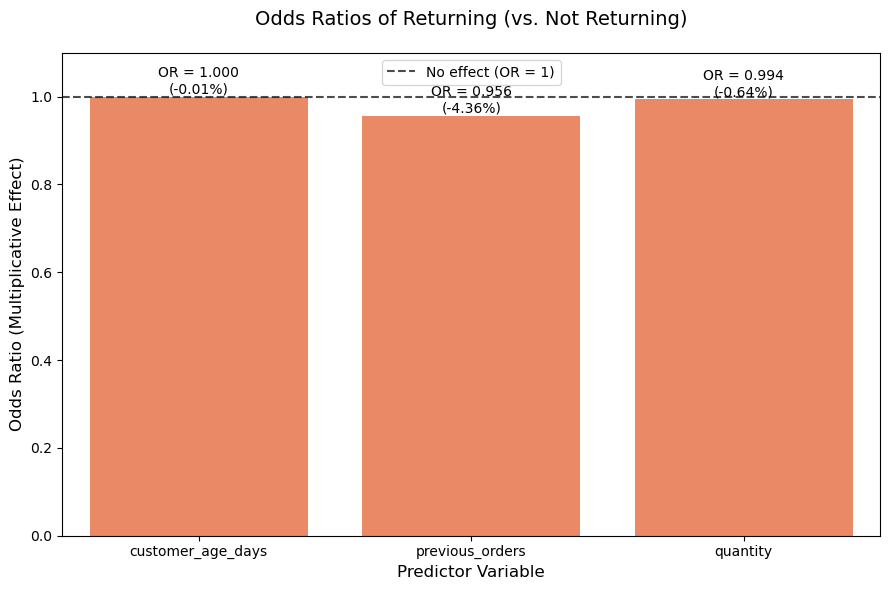

In [69]:
# Your data
coefs = {
    'customer_age_days': -0.00014616,
    'previous_orders': -0.04460081,
    'quantity': -0.00643153
}

# Create DataFrame and calculate Odds Ratios
df_coefs = pd.DataFrame(list(coefs.items()), columns=['variable', 'coefficient'])
df_coefs['odds_ratio'] = np.exp(df_coefs['coefficient'])

# --- Plotting ---
plt.figure(figsize=(9, 6))

# Use a diverging color palette: red for OR < 1 (decrease), blue for OR > 1 (increase)
# Since all are < 1, we'll use a sequential palette, or we can use a custom condition.
colors = ['coral' if or_val < 1 else 'steelblue' for or_val in df_coefs['odds_ratio']]

# Create the barplot
ax = sns.barplot(
    data=df_coefs, 
    x='variable', 
    y='odds_ratio', 
    palette=colors
)

# Draw the null line at y=1
ax.axhline(y=1, color='black', linestyle='--', alpha=0.7, label='No effect (OR = 1)')

# Add value labels on top of each bar
for i, (idx, row) in enumerate(df_coefs.iterrows()):
    or_val = row['odds_ratio']
    # Calculate percentage decrease/increase for the label
    pct_change = (or_val - 1) * 100
    label = f'OR = {or_val:.3f}\n({pct_change:+.2f}%)'  # + sign shows decrease clearly
    ax.text(i, or_val + 0.001, label, ha='center', va='bottom', fontsize=10)

# Styling
plt.title('Odds Ratios of Returning (vs. Not Returning)', fontsize=14, pad=20)
plt.ylabel('Odds Ratio (Multiplicative Effect)', fontsize=12)
plt.xlabel('Predictor Variable', fontsize=12)
plt.ylim(0, 1.1)  # Since all ORs are < 1, this zooms in nicely. Adjust if needed.
plt.legend()
plt.tight_layout()
plt.show()